## Deep Set Embedding Tutorial
This tutorial demonstrates how to use the lampe backend with a custom Deep Set embedding network.

In [ ]:
%load_ext autoreload
%autoreload 2

# Standard library and deep learning imports
import numpy as np
import scipy as sps
import matplotlib.pyplot as plt

# PyTorch
import torch
import torch.nn as nn
from torch.utils import data

# PyTorch Geometric imports for graph/set data
from torch_geometric.data import Data as PYGData
from torch_geometric.loader.dataloader import Collater
from torch_geometric.nn import global_mean_pool, global_max_pool

# ltu-ili imports for inference and validation
import ili
from ili.dataloaders import TorchLoader
from ili.inference import InferenceRunner
from ili.validation.metrics import PlotSinglePosterior, PosteriorCoverage

import wandb

# Set device for PyTorch (GPU if available, else CPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Embedding configurations

In [2]:
# Matt's original embedding
EMBEDDING_FLAVOUR = 'matts'
EMBEDDING_OUTPUT_SIZE = 8
EMBEDDING_HIDDEN_LAYERS = 2
EMBEDDING_HIDDEN_SIZE = 32

In [3]:
fsavebase = '3_param_trained_models'

NUM_SAMPLES = 2000
#NUM_SAMPLES = 20000

out_dir = f'./{fsavebase}/{NUM_SAMPLES}totalsamples_{EMBEDDING_FLAVOUR}embedding'

## Load my apt simulations

In [4]:
fbase = '/home/puehlengt/appletree/notebooks/'
fname = f'{fbase}/harvested_testsims_3params.npy'

aa = np.load(fname, allow_pickle=True).item()
param_bag = aa['param_bag'] # list of dictionary of the params and values
events_bag = aa['events_bag'] # list of array, (2, n) in shape

In [5]:
apt_param_config = {"g1": {
        "prior_type": "norm",
        "prior_args": {
            "mean": 0.1367,
            "std": 0.001
        },
        "allowed_range": [
            0,
            1.0
        ],
        "init_mean": 0.1367,
        "init_std": 0.001,
        "unit": "PE/photon",
        "doc": "g1"
    },
    "g2": {
        "prior_type": "norm",
        "prior_args": {
            "mean": 16.85,
            "std": 0.46
        },
        "allowed_range": [
            0,
            100.0
        ],
        "init_mean": 16.85,
        "init_std": 0.46,
        "unit": "PE/electron",
        "doc": "g2"
    },
    "ambe_nr_rate": {
        "prior_type": "free",
        "prior_args": {},
        "allowed_range": [
            0,
            10000000000.0
        ],
        "init_mean": 5500,
        "init_std": 100,
        "unit": "1",
        "doc": "total number of events in the AmBe NR calibration"
    }
}

In [6]:
dataset = []
params = []
cnt = 0
for _ind in range(len(events_bag)):
    if cnt >= NUM_SAMPLES:
        break
    _events = torch.tensor(events_bag[_ind].T)
    _params = torch.tensor([_ for _ in param_bag[_ind].values()]).reshape(1, -1)

    dataset.append(PYGData(x=_events, y=_params))
    params.append(_params)
    cnt += 1

# Collect all true param values for later evaluation # not sure what for, but okie
params = np.concatenate(params, axis=0)

_, DIM_THETA = _params.shape
_, DIM_DATA = _events.shape

In [7]:
print(f'Dataset loaded with {len(dataset):.0e} samples, each with {DIM_DATA} data dimensions and {DIM_THETA} parameter dimensions.')

Dataset loaded with 2e+03 samples, each with 2 data dimensions and 3 parameter dimensions.


In [8]:
zzparams = []
cnt = 0
for _ind in range(len(events_bag)):
    if cnt >= NUM_SAMPLES:
        break
    _params = [_ for _ in param_bag[_ind].values()]
    zzparams.append(_params)
    cnt += 1
zzparams = np.array(zzparams)

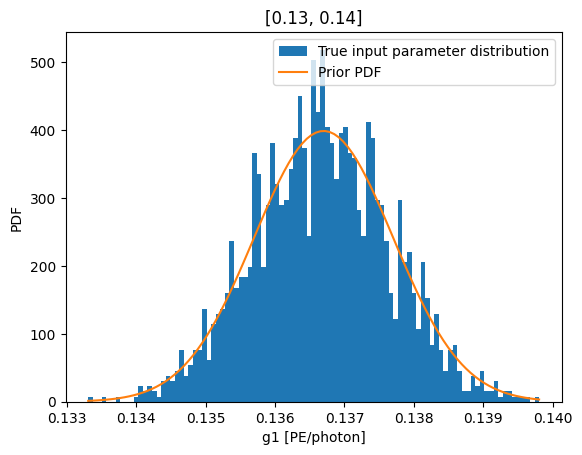

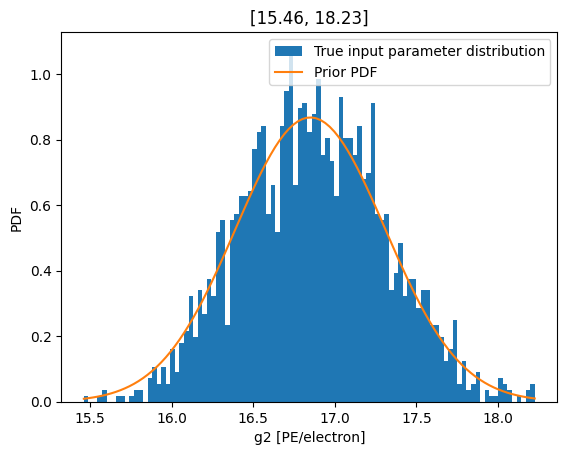

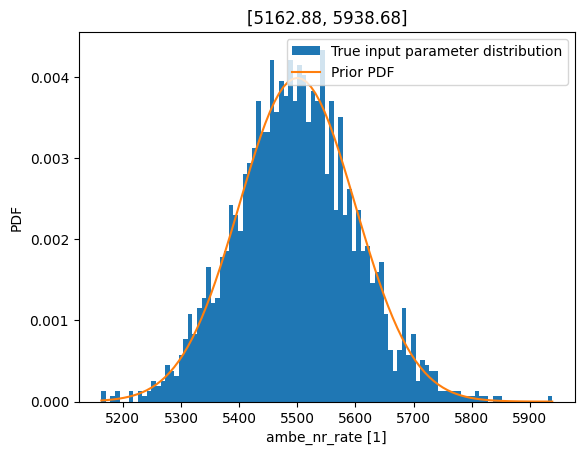

In [9]:
for _ii, (key, val) in enumerate(apt_param_config.items()):
    zzz = zzparams[:, _ii]
    zzmin, zzmax = zzz.min(), zzz.max()
    zzxx = np.linspace(zzmin, zzmax, 100)

    try:
        zzmean = val['prior_args']['mean']
        zzstd = val['prior_args']['std']
    except:
        zzmean = val['init_mean']
        zzstd = val['init_std']

    plt.figure()
    plt.hist(zzz, bins=zzxx, density=True, label='True input parameter distribution')
    plt.plot(zzxx, sps.stats.norm.pdf(zzxx, loc=zzmean, scale=zzstd), label='Prior PDF')
    plt.title(f'[{zzmin:.2f}, {zzmax:.2f}]')
    plt.xlabel(f'{key} [{val["unit"]}]')
    plt.ylabel('PDF')
    plt.legend()

In [10]:
type(dataset), len(dataset), dataset[0]

(list, 2000, Data(x=[5457, 2], y=[1, 3]))

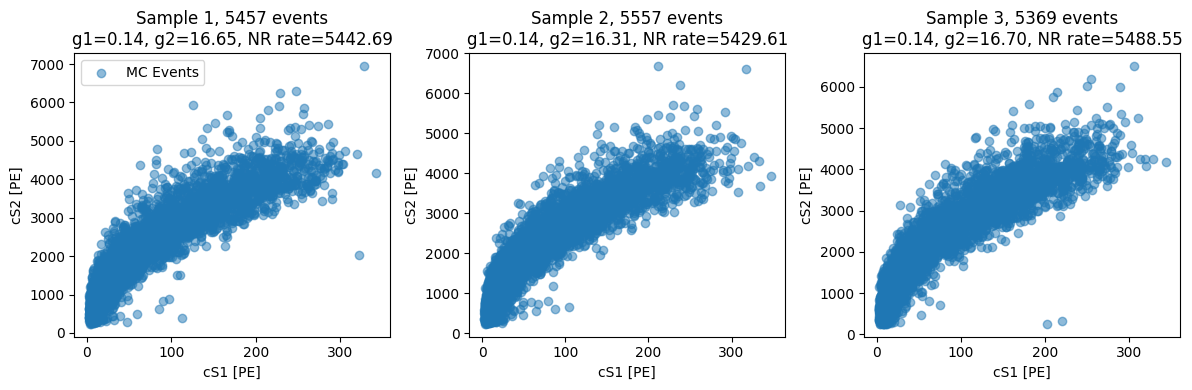

In [11]:
# Plot the first 3 samples from the dataset to visualize the events and their parameters
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for i in range(3):
    data_sample = dataset[i]
    x_pts = data_sample.x.numpy()
    theta_val = data_sample.y.numpy().flatten()

    axes[i].scatter(x_pts[:, 0], x_pts[:, 1], alpha=0.5, label='MC Events')
    axes[i].set_xlabel('cS1 [PE]')
    axes[i].set_ylabel('cS2 [PE]')

    #axes[i].set_xlim(-5, 5)
    #axes[i].set_ylim(-5, 5)
    axes[i].set_title(f'Sample {i+1}, {(len(x_pts))} events\ng1={theta_val[0]:.2f}, g2={theta_val[1]:.2f}, NR rate={theta_val[2]:.2f}')
    if i == 0:
        axes[i].legend()
plt.tight_layout()
plt.show()

## Data loaders

In [12]:
# Define custom dataset and dataloaders

# PyTorch Dataset wrapper for our generated point sets
class GraphData(data.Dataset):
    def __init__(self, data):
        self.data = data

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]


graph_dataset = GraphData(dataset)
# Use PyTorch Geometric's Collater to handle batching of variable-size sets
collater = Collater(dataset=graph_dataset, follow_batch='y')


def collate_fn(batch):
    batch = collater(batch)
    return batch, batch.y

In [ ]:
# Only seeding the permutation for reproducibility of train/val/test split, not the model training itself
np.random.seed(42)

# Define test set size and validation fraction (after removing test set)
n_test = 10
validation_fraction = 0.1

# Randomly permute all indices
permuted_idx = np.random.permutation(NUM_SAMPLES)

# Split into test and remaining
idx_test = permuted_idx[:n_test]
idx_remaining = permuted_idx[n_test:]

# Define training and validation set sizes
n_remaining = len(idx_remaining)
n_train = int((1 - validation_fraction) * n_remaining)
n_val = n_remaining - n_train

# Split remaining into training and validation
idx_train = idx_remaining[:n_train]
idx_val = idx_remaining[n_train:]

# Create PyTorch DataLoaders
train_loader = data.DataLoader(
    graph_dataset, batch_size=32, collate_fn=collate_fn,
    sampler=data.SubsetRandomSampler(idx_train), drop_last=True
)

val_loader = data.DataLoader(
    graph_dataset, batch_size=32, collate_fn=collate_fn,
    sampler=data.SubsetRandomSampler(idx_val)
)

''' # Don't need loader for test set for now, but mabbe need it in the future
test_loader = data.DataLoader(
    graph_dataset, batch_size=32, collate_fn=collate_fn,
    sampler=data.SubsetRandomSampler(idx_test)
)
'''

# Wrap in TorchLoader
loader = TorchLoader(train_loader, val_loader)

In [ ]:
# Design a simple Deep Set embedder
class DeepSet(nn.Module):
    def __init__(self, in_channels, hidden_layers, hidden_channels, out_channels):
        super().__init__()
        # Node MLP applied independently to each point/node
        layers = []

        # First hidden layer
        layers.append(nn.Linear(in_channels, hidden_channels))

        # Additional hidden layers, must end with linear before pooling
        for _ in range(hidden_layers - 1):
            layers.append(nn.ReLU())
            layers.append(nn.Linear(hidden_channels, hidden_channels))

        self.node_mlp = nn.Sequential(*layers)

        # Global MLP applied to the aggregated global features
        self.global_mlp = nn.Sequential(
            nn.Linear(hidden_channels * 2, hidden_channels), # cause pooling max and mean, so 2x hidden_channels
            nn.ReLU(),
            nn.Linear(hidden_channels, out_channels)
        )

    def forward(self, x):
        node_features, batch = x.x, x.batch

        # Apply node-wise transformation
        node_embed = self.node_mlp(node_features)

        # Pool features globally using both mean and max to ensure permutation invariance
        mean_pool = global_mean_pool(node_embed, batch)
        max_pool = global_max_pool(node_embed, batch)

        # Concatenate pooled features and apply global transformation
        global_embed = torch.cat([mean_pool, max_pool], dim=1)
        
        return self.global_mlp(global_embed)

embedding = DeepSet(in_channels=DIM_DATA,
                    hidden_layers=EMBEDDING_HIDDEN_LAYERS,
                    hidden_channels=EMBEDDING_HIDDEN_SIZE,
                    out_channels=EMBEDDING_OUTPUT_SIZE)

In [15]:
embedding

DeepSet(
  (node_mlp): Sequential(
    (0): Linear(in_features=2, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=32, bias=True)
  )
  (global_mlp): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=8, bias=True)
  )
)

### Priors from apt config

In [16]:
means = []
stds = []
low_bounds = []
high_bounds = []

for param_name, param_info in apt_param_config.items():    
    # Get mean: from prior_args if exists, otherwise from init_mean
    if 'mean' in param_info.get('prior_args', {}):
        mean = param_info['prior_args']['mean']
    else:
        mean = param_info['init_mean']
    
    # Get std: from prior_args if exists, otherwise from init_std
    if 'std' in param_info.get('prior_args', {}):
        std = param_info['prior_args']['std']
    else:
        std = param_info['init_std']
    
    # Get allowed range (truncation bounds)
    allowed_range = param_info['allowed_range']
    low = allowed_range[0]
    high = allowed_range[1]
    
    means.append(mean)
    stds.append(std)
    low_bounds.append(low)
    high_bounds.append(high)

In [17]:
prior = ili.utils.distributions_pt.IndependentTruncatedNormal(
    loc=means,
    scale=stds,
    low=low_bounds,
    high=high_bounds,
    device=device
)

In [18]:
prior, type(prior)

(IndependentTruncatedNormal(_UnivariateTruncatedNormal(a: torch.Size([3]), b: torch.Size([3])), 1),
 ili.utils.distributions_pt.IndependentTruncatedNormal)

In [19]:
'''
# Living lyfe dangerously, define a uniform prior over the parameter space
prior = ili.utils.Uniform(
    low=low_bounds,
    high=high_bounds,
    device=device
)
'''

# Define Neural Density Estimators (NDEs) - here using Neural Spline Flows (NSF)
nets = [
    ili.utils.load_nde_lampe(
        model='nsf', hidden_features=32, num_transforms=3,
        # Pass the custom Deep Set embedding network to compress the data
        embedding_net=embedding, x_normalize=False, device=device
    )
]

# Specify training hyperparameters
train_args = {
    'training_batch_size': 32,
    'learning_rate': 1e-4,
    'stop_after_epochs': 20
}

# Initialize the inference runner with the 'lampe' backend for Neural Posterior Estimation (NPE)
runner = InferenceRunner.load(
    backend='lampe',
    engine='NPE',
    prior=prior,
    nets=nets,
    device=device,
    train_args=train_args,
    proposal=None, # defaults to prior if None
    out_dir=out_dir,
)

In [20]:
# Run the inference training process to learn the posterior
posterior_ensemble, summaries = runner(loader=loader)

INFO:root:MODEL INFERENCE CLASS: NPE
INFO:root:Training model 1 / 1.
0 epochs [00:00, ? epochs/s]/home/puehlengt/.local/lib/python3.11/site-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
102 epochs [04:35,  2.70s/ epochs, loss=0.653, loss_val=1.06] 
INFO:root:It took 275.07030487060547 seconds to train models.
INFO:root:Saving model to 3_param_trained_models/2000totalsamples_mattsembedding


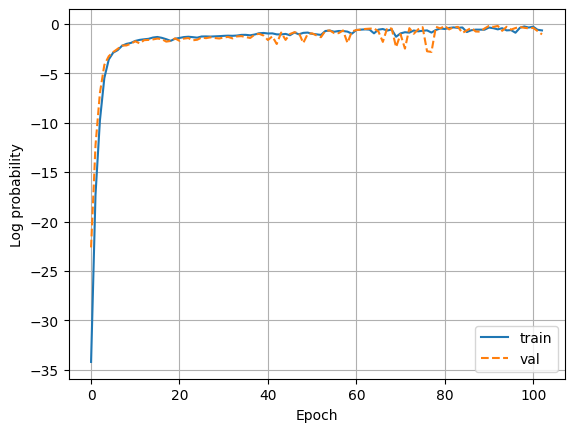

In [21]:
# Plot training and validation log probabilities over epochs
fig, ax = plt.subplots()
for i, m in enumerate(summaries):
    ax.plot(m['training_log_probs'], ls='-', label="train")
    ax.plot(m['validation_log_probs'], ls='--', label="val")
ax.set_xlabel('Epoch')
ax.set_ylabel('Log probability')
ax.grid()
ax.legend()

## Pick a set for testing
Fake x_obs

In [22]:
# Select a single validation sample to evaluate
ind = 0
test_idx = idx_test[ind]

x_ = graph_dataset[test_idx] # Events. torch_geometric.data.data.Data object lol
y_ = x_.y[0].numpy() # True parameter values

torch.manual_seed(1234)

# Sample from the trained posterior ensemble
samples = posterior_ensemble.sample((1000,), x_)

# Evaluate the log probability of the samples
log_prob = posterior_ensemble.log_prob(samples, x_)

samples = samples.cpu().numpy()
log_prob = log_prob.cpu().numpy()

INFO:root:Sampling models with [1000] samples each.
Drawing 1000 posterior samples: 100%|██████████| 1000/1000 [00:00<00:00, 30414.67it/s]


In [23]:
type(samples), samples.shape, log_prob.shape, samples[0]

(numpy.ndarray,
 (1000, 3),
 (1000,),
 array([1.3512804e-01, 1.6840776e+01, 5.4448740e+03], dtype=float32))

Text(0, 0.5, 'cS2 [PE]')

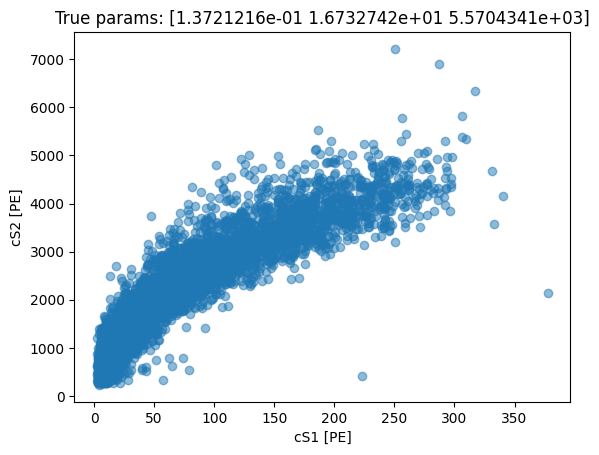

In [24]:
test = x_.x.cpu().numpy()
plt.scatter(test[:, 0], test[:, 1], alpha=0.5, label='MC Events')
plt.title(f'True params: {y_}')
plt.xlabel('cS1 [PE]')
plt.ylabel('cS2 [PE]')

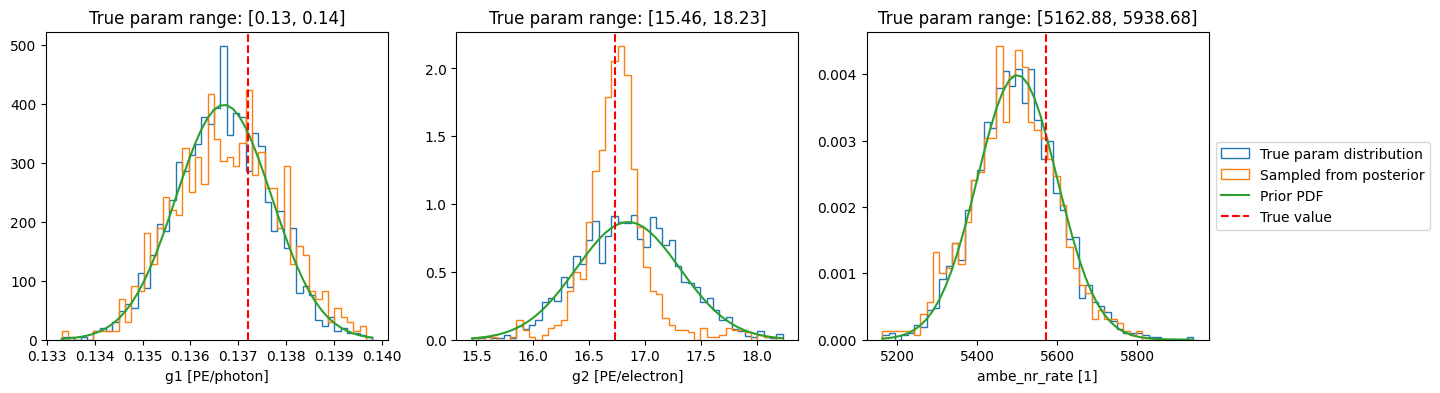

In [25]:
plt.figure(figsize=(15, 4))
for _ii, (key, val) in enumerate(apt_param_config.items()):
    zzz = zzparams[:, _ii]
    zzmin, zzmax = zzz.min(), zzz.max()
    zzxx = np.linspace(zzmin, zzmax, 50)

    try:
        zzmean = val['prior_args']['mean']
        zzstd = val['prior_args']['std']
    except:
        zzmean = val['init_mean']
        zzstd = val['init_std']

    plt.subplot(131+_ii)
    plt.hist(zzz, bins=zzxx, density=True, histtype='step', label='True param distribution')
    plt.hist(samples[:, _ii], bins=zzxx, density=True, histtype='step', label=f'Sampled from posterior')
    plt.plot(zzxx, sps.stats.norm.pdf(zzxx, loc=zzmean, scale=zzstd), label='Prior PDF')
    plt.axvline(y_[_ii], color='red', linestyle='--', label='True value')

    plt.title(f'True param range: [{zzmin:.2f}, {zzmax:.2f}]')
    plt.xlabel(f'{key} [{val["unit"]}]')

    if _ii == DIM_THETA-1:
        plt.legend(loc='center left', bbox_to_anchor=(1., 0.5))


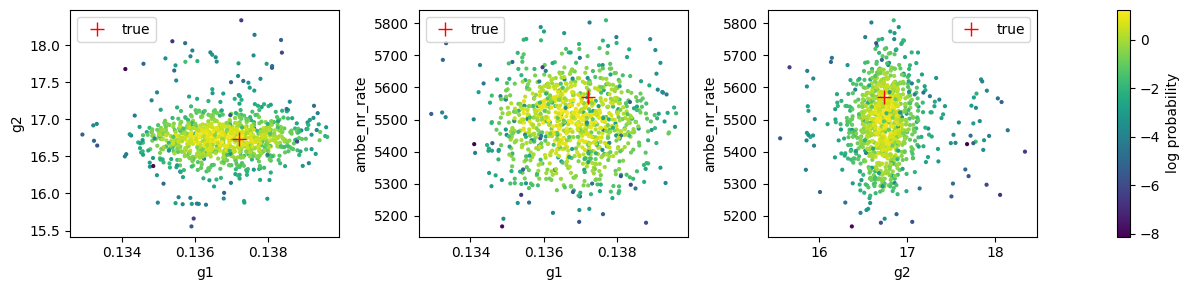

In [26]:
from itertools import combinations

# Visualize the posterior samples compared to the true value for 3D
n_combinations = DIM_THETA * (DIM_THETA - 1) // 2  # 3 choose 2 = 3

# Create subplots: one for each pair combination + one colorbar
fig, axs = plt.subplots(1, n_combinations + 1, 
                        figsize=(3 * (n_combinations + 1), 3),
                        gridspec_kw={'width_ratios': [1] * n_combinations + [0.05]})

# Get all pair combinations of parameters
param_pairs = list(combinations(range(DIM_THETA), 2))
param_names = [_ for _ in apt_param_config.keys()]

# Plot each combination
for idx, (i, j) in enumerate(param_pairs):
    # Scatter plot of samples
    im = axs[idx].scatter(samples[:, i], samples[:, j],
                          c=log_prob, s=4, cmap='viridis')
    axs[idx].set_xlabel(param_names[i])
    axs[idx].set_ylabel(param_names[j])
    
    # Plotting true value
    axs[idx].plot(y_[i], y_[j], 'r+', markersize=10, label='true')
    axs[idx].legend()

# Add colorbar to the last subplot
plt.colorbar(im, label='log probability', cax=axs[-1])

plt.tight_layout()
plt.show()


INFO:root:Sampling models with [1000] samples each.
Drawing 1000 posterior samples: 100%|██████████| 1000/1000 [00:00<00:00, 54174.58it/s]


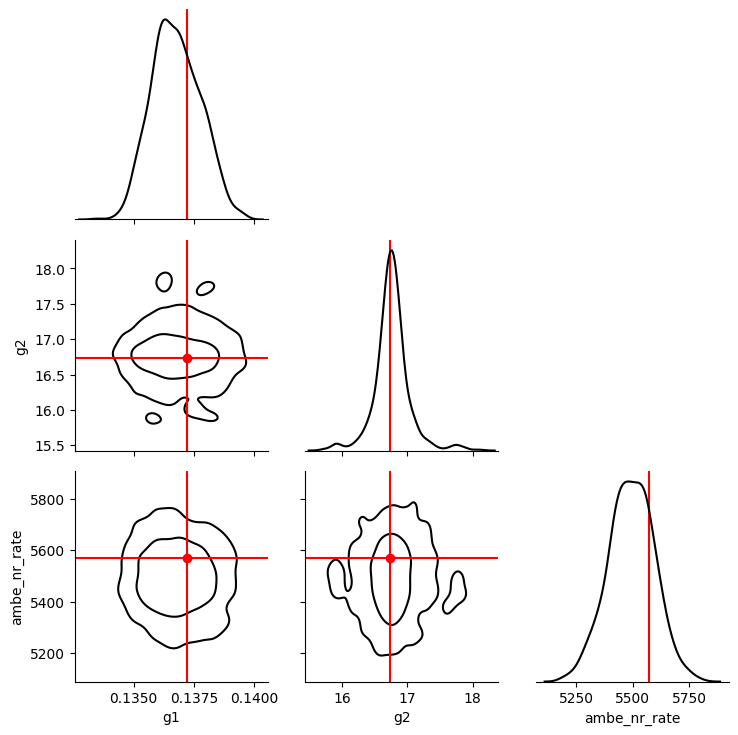

In [27]:
metric = PlotSinglePosterior(
    num_samples=1000, sample_method='direct',
    labels=param_names,
)
fig = metric(
    posterior=posterior_ensemble,
    x_obs=x_, theta_fid=y_
)

100%|██████████| 100/100 [00:22<00:00,  4.50it/s]


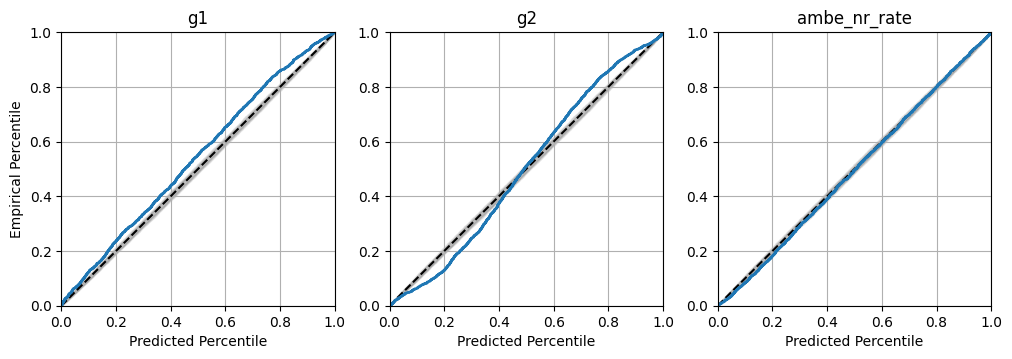

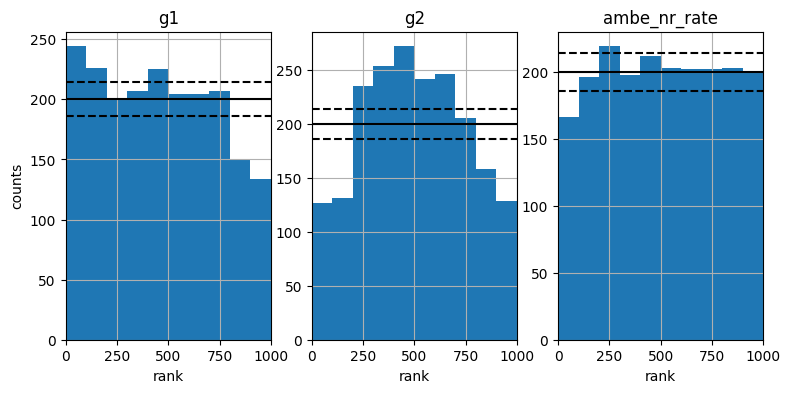

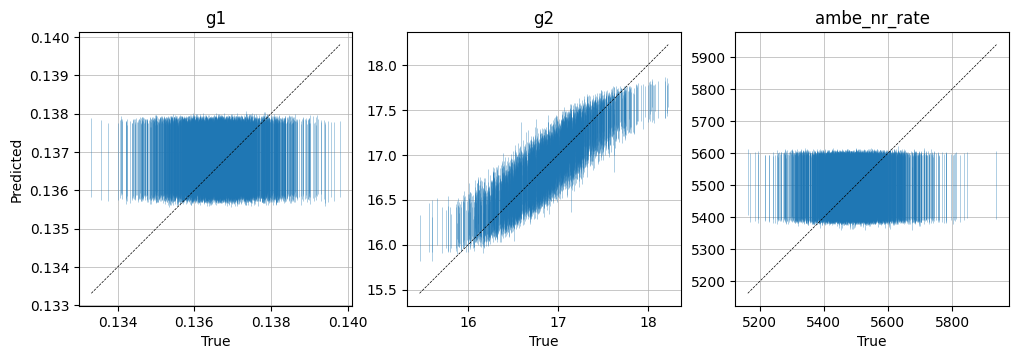

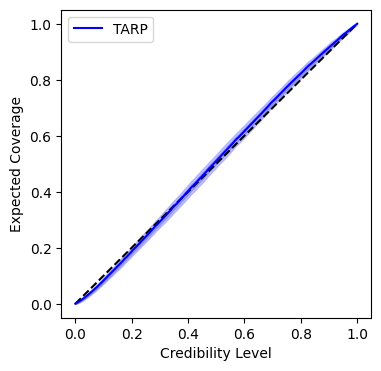

In [28]:
# PosteriorCoverage
metric = PosteriorCoverage(
    num_samples=1000, sample_method='direct',
    out_dir=None, labels=param_names,
    plot_list=["coverage", "histogram", "predictions", "tarp"],
    save_samples=True
)
fig = metric(
    posterior=posterior_ensemble,
    x=graph_dataset, theta=params
)